## 2. Data
*Instructions: Describe the dataset, its source, and why it was chosen. Detail the preprocessing steps.*

**Dataset Source:** PUMS (Public Use Microdata Sample) from the US Census Bureau.

In [11]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import logging
from datetime import datetime
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import joblib

# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
logging.basicConfig(level=logging.INFO, format='%(message)s')
logger = logging.getLogger()

# Define Paths
DATA_RAW = '00 data/raw/psam_p38.csv'

### 2.1 Data Understanding & Exploration

**Objectives:**
*   **Initial Analysis:** Inspect data shape, missing values, and data quality.
*   **Statistical Checks:** Analyze variance, correlation, and mutual information.
*   **Health Indicators:** Explore the distribution of health insurance coverage types and their combinations.
*   **Feature Distribution:** Visualize key demographic and economic features.

#### Load Data and Filter Age

In [35]:
print("Loading raw data...")
df_raw = pd.read_csv(DATA_RAW)

Loading raw data...


#### Data Exploration
Within this step we are looking at
- the **shape** of the dataframe,
- **missing values**,
- **correlation** with HINS4 (Medicaid),
- **mutual information** with HINS4 (medicaid) and
- **class imbalance** and **combinations** of different insurance types (HINS)

##### Shape

In [36]:
# Head & Shape
print(f"Data Shape: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")
display(df_raw.head(5))

Data Shape: 8,403 rows, 287 columns


,RT,SERIALNO,DIVISION,SPORDER,PUMA,REGION,STATE,ADJINC,PWGTP,AGEP,...,PWGTP71,PWGTP72,PWGTP73,PWGTP74,PWGTP75,PWGTP76,PWGTP77,PWGTP78,PWGTP79,PWGTP80
0,P,2023GQ0000978,4,1,600,2,38,1019518,5,41,...,7,6,5,5,7,7,4,4,5,5
1,P,2023GQ0001384,4,1,600,2,38,1019518,113,22,...,86,97,131,13,120,17,107,108,7,12
2,P,2023GQ0002487,4,1,600,2,38,1019518,129,21,...,129,229,113,12,243,256,10,139,136,12
3,P,2023GQ0002750,4,1,300,2,38,1019518,24,20,...,25,32,55,19,16,26,22,41,31,23
4,P,2023GQ0003212,4,1,300,2,38,1019518,37,19,...,66,47,29,35,2,35,37,33,32,37


##### Missing Values


--- Missing Values ---

Columns with Missing Values:
           Missing Count Percentage
GCM                 8364     99.54%
GCR                 8323     99.05%
SFN                 8309     98.88%
SFR                 8309     98.88%
CITWP               8307     98.86%
DRAT                8217     97.79%
FOD2P               8182     97.37%
YOEP                8107     96.48%
DECADE              8107     96.48%
LANP                8032     95.58%
ENG                 8032     95.58%
FHINS5C             7991     95.10%
MLPB                7791     92.72%
MLPIK               7791     92.72%
MLPA                7791     92.72%
MLPCD               7791     92.72%
MLPJ                7791     92.72%
MLPFG               7791     92.72%
MLPE                7791     92.72%
VPS                 7791     92.72%
MLPH                7791     92.72%
DRATX               7681     91.41%
MIGSP               7436     88.49%
MIGPUMA             7436     88.49%
FHINS4C             7326     87.18%
FER       

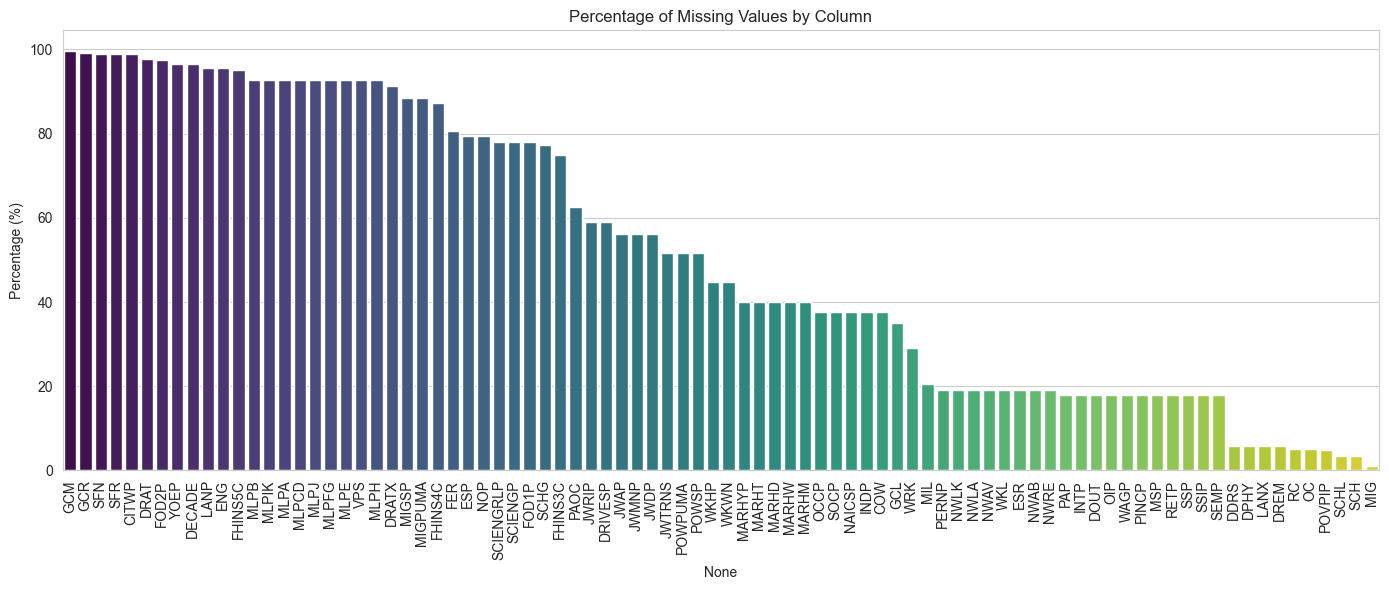

In [37]:
# Missing Values
print("\n--- Missing Values ---")
missing = df_raw.isnull().sum()
missing = missing[missing > 0]

missing_pct = (missing / len(df_raw)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})

# Sort by percentage descending
missing_df = missing_df.sort_values('Percentage', ascending=False)

# List with column and percentage
print("\nColumns with Missing Values:")
print(missing_df.to_string(formatters={'Percentage': '{:,.2f}%'.format}))

# Chart: Distribution of columns with missing values (ordered by percentage)
plt.figure(figsize=(14, 6))
sns.barplot(x=missing_df.index, y=missing_df['Percentage'], palette='viridis', order=missing_df.index)
plt.title('Percentage of Missing Values by Column')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

##### Correlation


--- Correlation with Medicaid (HINS4) ---

Features Correlated with Medicaid:
PUBCOV       0.519798
PRIVCOV      0.489279
ESP          0.427040
NOP          0.398133
POVPIP       0.358437
HINS1        0.329730
SFR          0.261609
DOUT         0.250310
RACAIAN      0.235053
RELSHIPP     0.230825
FHINS5C      0.226893
DREM         0.213676
RACWHT       0.200344
ESR          0.199482
WRK          0.198248
WKL          0.195287
MSP          0.192167
DIS          0.184904
DDRS         0.184124
MAR          0.183422
HINS7        0.181869
DPHY         0.167458
SSIP         0.162775
ANC1P        0.157813
WAGP         0.156859
PINCP        0.153870
PERNP        0.151823
SCHL         0.150454
RAC2P        0.150274
WKWN         0.149211
CITWP        0.124136
RC           0.117810
FHINS2P      0.113422
NWLK         0.112791
RAC1P        0.111591
PAP          0.111582
FHICOVP      0.110620
SPORDER      0.108072
FHINS6P      0.107451
FPRIVCOVP    0.107171
FPUBCOVP     0.104489
FHINS5P      0.1044

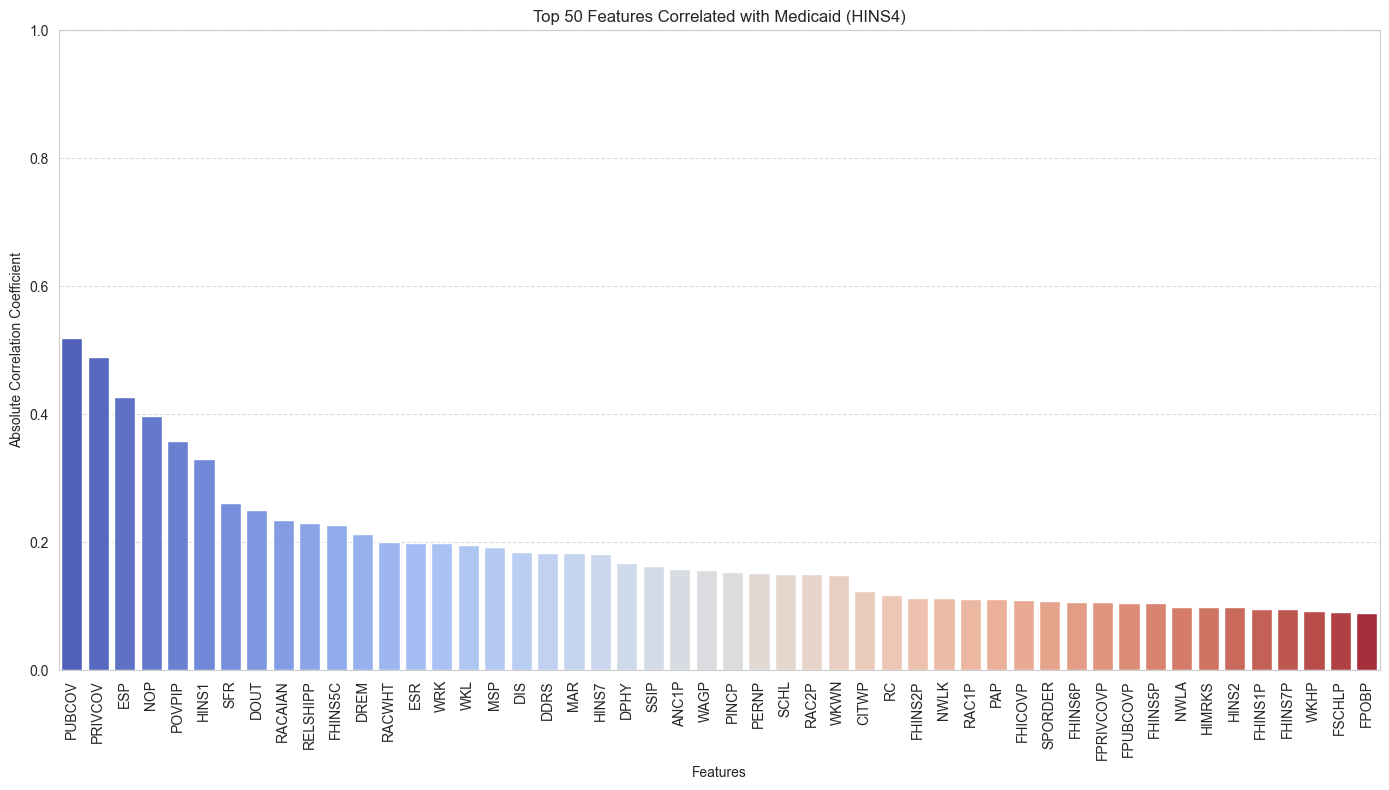

In [38]:
# Correlation with Medicaid (HINS4)
print("\n--- Correlation with Medicaid (HINS4) ---")

# Define numeric columns
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns

# Calculate correlation of all numeric features with HINS4
corr_with_medicaid = df_raw[numeric_cols].corrwith(df_raw['HINS4']).abs().sort_values(ascending=False)

# Remove HINS4 itself from the results
corr_with_medicaid = corr_with_medicaid.drop('HINS4', errors='ignore')

# Print top correlated features
print("\nFeatures Correlated with Medicaid:")
print(corr_with_medicaid.to_string())

# Get top 50 features
top_50 = corr_with_medicaid.head(50)

# Print highly correlated features
high_corr = top_50[top_50 > 0.3]  # Adjust threshold as needed
print(f"\nFeatures with correlation > 0.3 to Medicaid: {len(high_corr)} features")

# Plot as a bar chart with switched axes
plt.figure(figsize=(14, 8))
sns.barplot(x=top_50.index, y=top_50.values, palette='coolwarm')
plt.title('Top 50 Features Correlated with Medicaid (HINS4)')
plt.xlabel('Features')
plt.ylabel('Absolute Correlation Coefficient')
plt.ylim(0, 1)  # Correlation ranges from 0 to 1
plt.xticks(rotation=90)  # Rotate feature names for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


##### Mutual Information


--- Mutual Information Analysis ---
Features with Mutual Information towards Medicaid:
PUBCOV       0.147375
PRIVCOV      0.104274
POVPIP       0.084606
HINS1        0.053517
PINCP        0.045807
RELSHIPP     0.044348
ANC1P        0.036540
WAGP         0.034993
WKWN         0.033893
OCCP         0.033418
PERNP        0.033093
WKHP         0.032955
POWPUMA      0.030713
JWRIP        0.028158
INDP         0.028140
JWAP         0.027461
NOP          0.027382
WRK          0.027082
RAC3P        0.026778
WKL          0.026719
ESR          0.026671
RAC2P        0.026444
MSP          0.026098
MAR          0.023165
DOUT         0.022758
RAC1P        0.022587
ESP          0.022583
SCIENGP      0.022325
POWSP        0.022022
JWTRNS       0.022022
SCHL         0.021616
RACAIAN      0.021099
JWMNP        0.020667
RACWHT       0.019594
JWDP         0.018820
COW          0.018121
DREM         0.018017
MARHYP       0.017931
NWLK         0.017927
DDRS         0.017665
DRIVESP      0.017489
NWAB      

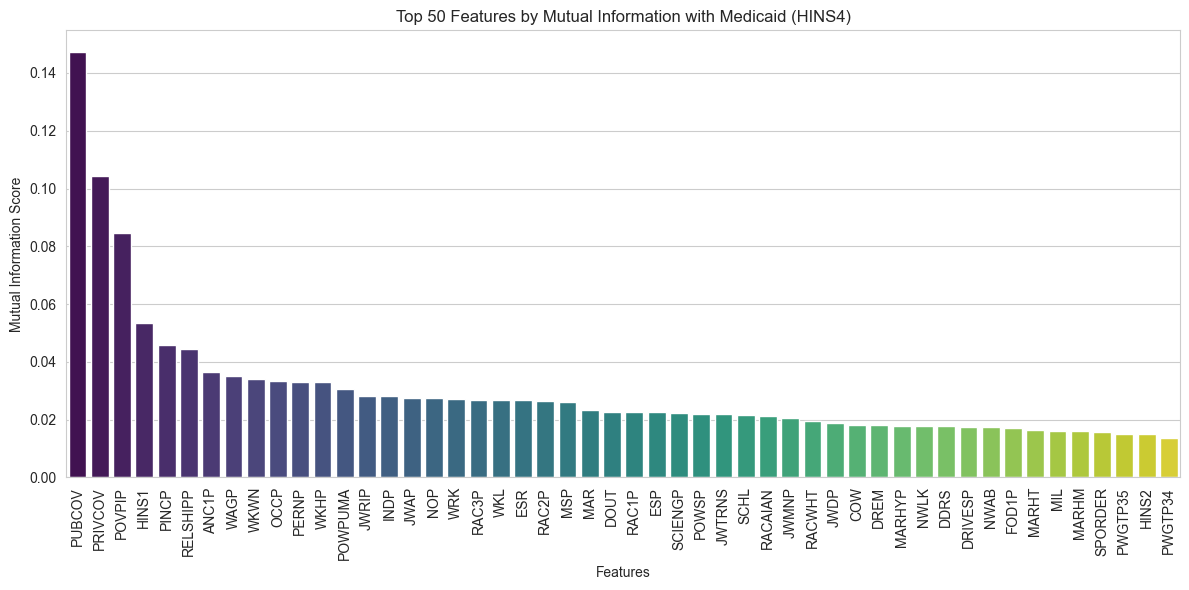

In [39]:
# Mutual Information
print("\n--- Mutual Information Analysis ---")
# Sample for speed
sample_df = df_raw.sample(min(5000, len(df_raw)), random_state=42).fillna(0)
X_mi = sample_df.select_dtypes(include=[np.number]).drop(columns=['HINS4'], errors='ignore')
y_mi = sample_df['HINS4']

mi = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_series = pd.Series(mi, index=X_mi.columns).sort_values(ascending=False)

# Print ALL features by Mutual Information (sorted)
print("Features with Mutual Information towards Medicaid:")
print(mi_series.to_string())

# Plot distribution of TOP 50 Mutual Information scores
plt.figure(figsize=(12, 6))
top_50_mi = mi_series.head(50)  # Get top 50 features
sns.barplot(x=top_50_mi.index, y=top_50_mi.values, palette='viridis')
plt.title('Top 50 Features by Mutual Information with Medicaid (HINS4)')
plt.xlabel('Features')
plt.ylabel('Mutual Information Score')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


##### Class Imbalance & Combinations


--- Health Indicators ---
Class Imbalance (HINS4 - Medicaid):
HINS4
No     0.871831
Yes    0.128169
Name: proportion, dtype: float64


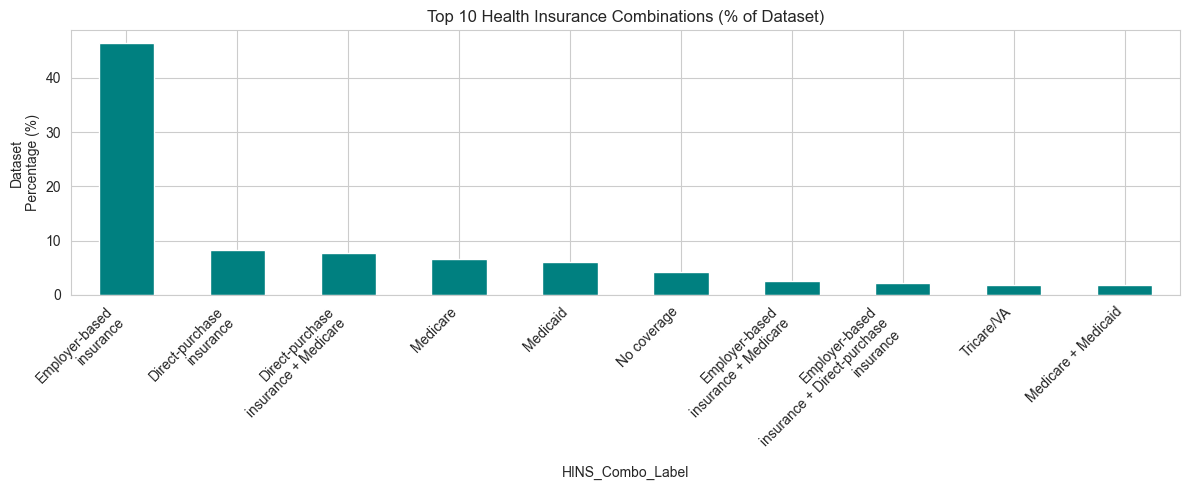

In [40]:
# Health Indicators & Medicaid Class Imbalance
print("\n--- Health Indicators ---")
# Define HINS labels
hins_labels = {
    'HINS1': 'Employer-based\ninsurance',
    'HINS2': 'Direct-purchase\ninsurance',
    'HINS3': 'Medicare',
    'HINS4': 'Medicaid',
    'HINS5': 'Tricare/VA',
    'HINS6': 'Other public\ninsurance',
    'HINS7': 'No coverage'
}

# Replace 1/2 with descriptive labels for display
dist = df_raw['HINS4'].map({1: 'Yes', 2: 'No'}).value_counts(normalize=True)
print(f"Class Imbalance (HINS4 - {hins_labels['HINS4']}):")
print(dist)

# HINS Combinations Chart with labels and percentages
hins_cols = sorted([c for c in df_raw.columns if c.startswith('HINS') and len(c) == 5])
if hins_cols:
    # Create a mapping function for the combination labels
    def map_hins_combo(row):
        combo_parts = []
        for col in hins_cols:
            val = row[col]
            if val == 1:
                combo_parts.append(hins_labels.get(col, col))
        return ' + '.join(combo_parts) if combo_parts else 'No coverage'

    df_raw['HINS_Combo_Label'] = df_raw.apply(map_hins_combo, axis=1)
    top_combos = df_raw['HINS_Combo_Label'].value_counts(normalize=True).head(10) * 100  # Convert to percentage

    plt.figure(figsize=(12, 5))
    ax = top_combos.plot(kind='bar', color='teal')
    plt.title('Top 10 Health Insurance Combinations (% of Dataset)')

    # Set multiline x and y axis labels
    plt.ylabel('Dataset\nPercentage (%)')

    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha='right')

    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    plt.show()


## 3. Data Cleaning and Feature Engineering
In this section, we process the raw data through a structured pipeline involving attribute selection, data cleaning, and feature engineering.

### 3.1 Attribute Dropping
We filter the dataset to retain only the most relevant features for our analysis, grouped by domain. This step reduces dimensionality and focuses the model on impactful variables.

**Kept Features:**
*   **GROUP 1: Income & Affordability:** `WAGP`, `POVPIP`, `SEMP`, `INTP`, `RETP`, `SSP`, `SSIP`, `PAP`
*   **GROUP 2: Employment Quality:** `ESR`, `COW`, `WKL`, `OCCP_2digit`, `INDP_2digit`
*   **GROUP 3: Demographics & Life Stage:** `AGEP`, `SEX`, `MAR`, `MIG`, `NATIVITY`, `RAC1P`, `HISP`
*   **GROUP 4: Education:** `SCHL`, `SCH`
*   **GROUP 5: Health & Disability:** `DIS`, `DEAR`, `DEYE`, `DPHY`
*   **GROUP 6: Geography:** `STATE`, `PUMA`, `REGION`, `DIVISION`
*   **Target:** `HINS4` (Medicaid)

In [50]:
def filter_attributes(df_input):
    print("3.1 Attribute Dropping...")
    df = df_input.copy()
    
    # Define Feature Groups
    keep_cols = [
        # Relevant Health Indicators
        'HINS4', 'HINS1', 'HINS2', 'HINS3', 'HINS5', 'HINS6', 'HINS7',
        # Income & Affordability
        'WAGP', 'POVPIP', 'SEMP', 'INTP', 'RETP', 'SSP', 'SSIP', 'PAP',
        # Employment Quality
        'ESR', 'COW', 'WKL', 'OCCP', 'INDP',
        # Demographics
        'AGEP', 'SEX', 'MAR', 'MIG', 'NATIVITY', 'RAC1P', 'HISP',
        # Education
        'SCHL', 'SCH',
        # Health
        'DIS', 'DEAR', 'DEYE', 'DPHY',
        # Geography
        'STATE', 'PUMA', 'REGION', 'DIVISION'
    ]
    
    # Filter columns
    existing_cols = [c for c in keep_cols if c in df.columns]
    dropped_cols = len(df.columns) - len(existing_cols)
    
    df_selected = df[existing_cols].copy()
    print(f"Retained {len(existing_cols)} features. Dropped {dropped_cols} features.")
    return df_selected

# Execute 3.1
if os.path.exists(DATA_RAW):
    print("Loading raw data...")
    df_raw = pd.read_csv(DATA_RAW)
    # Age filter moved to 3.2
    
    df_3_1 = filter_attributes(df_raw)
    display(df_3_1.head(3))

Loading raw data...
3.1 Attribute Dropping...
Retained 37 features. Dropped 250 features.


,HINS4,HINS1,HINS2,HINS3,HINS5,HINS6,HINS7,WAGP,POVPIP,SEMP,...,SCHL,SCH,DIS,DEAR,DEYE,DPHY,STATE,PUMA,REGION,DIVISION
0,1,2,2,2,2,2,2,0.0,0.0,0.0,...,16.0,1.0,1,2,2,1.0,38,600,2,4
1,2,2,1,2,2,2,2,3000.0,NaN,0.0,...,19.0,2.0,2,2,2,2.0,38,600,2,4
2,2,1,1,2,2,2,2,5200.0,NaN,0.0,...,19.0,2.0,2,2,2,2.0,38,600,2,4


### 3.2 Data Cleaning
We perform a comprehensive data quality check and cleaning process.

**Steps:**
1.  **Duplicate Removal:** Identify and remove duplicate records to prevent bias.
2.  **Missing Value Analysis:** Calculate and visualize the extent of missing data.
3.  **Imputation:**
    *   **Numerical Features:** Imputed using the **Median** to be robust against outliers.
    *   **Categorical Features:** Imputed using the **Mode** (most frequent value).
    *   *Note:* For features with specific business logic (e.g., `ESR`, `WAGP`), we ensure imputation does not mask meaningful "Unknown" states required for Section 3.3.

3.2 Data Cleaning & Quality Check...
Filtering Age (18-65)...
Removed 3702 rows outside age range.
Removed 68 duplicate rows.

Applying Imputation...
 -> Imputed OCCP with 9920
 -> Imputed INDP with 9920
 -> Imputed COW with 9

Found 1 columns with missing values.
        Missing Count  Percentage
POVPIP            199    4.295273


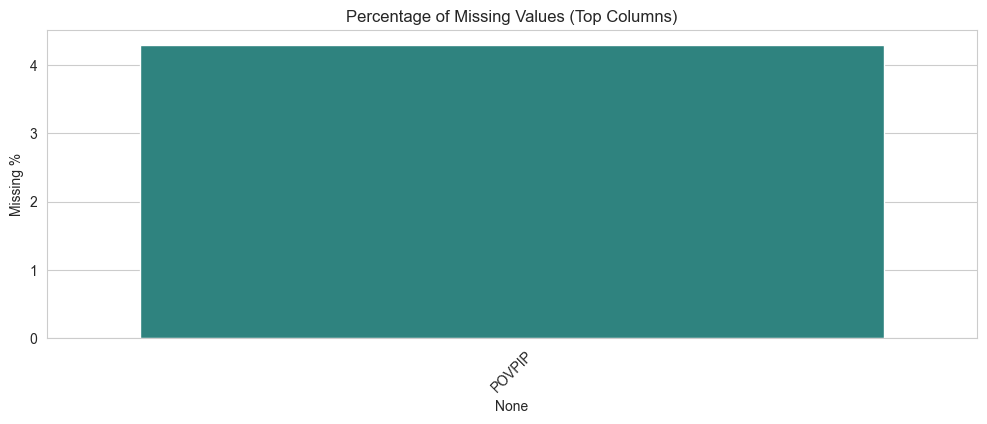

Data Cleaning Completed.
Shape after cleaning: (4633, 37)


In [52]:
def clean_data(df_input):
    print("3.2 Data Cleaning & Quality Check...")
    df = df_input.copy()

    # 0. Age Filter
    if 'AGEP' in df.columns:
        print("Filtering Age (18-65)...")
        initial_count = len(df)
        df = df[(df['AGEP'] >= 18) & (df['AGEP'] <= 65)]
        print(f"Removed {initial_count - len(df)} rows outside age range.")

    # 1. Duplicate Check
    initial_rows = len(df)
    df = df.drop_duplicates()
    dropped_rows = initial_rows - len(df)
    if dropped_rows > 0:
        print(f"Removed {dropped_rows} duplicate rows.")
    else:
        print("No duplicate rows found.")


    # 2. Imputation
    # We use a selective approach:
    # - Generic columns: Impute with Median/Mode.
    # - Key Business Columns (used in 3.3): We KEEP NaNs or fill with a placeholder to allow 3.3 logic to handle them (e.g. map to 'Unknown').
    
    # List of columns to SKIP generic imputation because 3.3 handles them specifically:
    # WAGP (Income), POVPIP (Poverty), ESR (Employment), COW (Worker Class), MAR (Marital), SCHL (Education)
    special_cols = ['WAGP', 'POVPIP', 'ESR', 'COW', 'MAR', 'SCHL', 'SCH', 'AGEP']
    
    print("\nApplying Imputation...")
    
    # Specific Imputation for OCCP and INDP
    for col in ['OCCP', 'INDP']:
        if col in df.columns:
             df[col] = df[col].fillna(9920)
             print(f" -> Imputed {col} with 9920")

    # Specific Imputation for COW
    if 'COW' in df.columns:
        df['COW'] = df['COW'].fillna(9)
        print(" -> Imputed COW with 9")

    # Numeric
    num_cols = df.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        if col not in special_cols and df[col].isnull().sum() > 0:
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
            print(f" -> Imputed {col} (Numeric) with Median: {median_val}")

    # Categorical
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    for col in cat_cols:
        if col not in special_cols and df[col].isnull().sum() > 0:
            mode_val = df[col].mode()[0]
            df[col] = df[col].fillna(mode_val)
            print(f" -> Imputed {col} (Categorical) with Mode: {mode_val}")

    # 3. Missing Value Analysis
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    
    if not missing.empty:
        print(f"\nFound {len(missing)} columns with missing values.")
        missing_pct = (missing / len(df)) * 100
        missing_report = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
        print(missing_report.sort_values('Percentage', ascending=False).head(10))
        
        # Visualization
        plt.figure(figsize=(12, 4))
        sns.barplot(x=missing_pct.index, y=missing_pct.values, palette='viridis')
        plt.title('Percentage of Missing Values (Top Columns)')
        plt.ylabel('Missing %')
        plt.xticks(rotation=45)
        plt.show()
    else:
        print("\nNo missing values found.")

    print("Data Cleaning Completed.")
    return df

# Execute 3.2
if 'df_3_1' in locals():
    df_3_2 = clean_data(df_3_1)
    print(f"Shape after cleaning: {df_3_2.shape}")

### 3.3 New Data Frame
We create a new dataframe with engineered features based on business logic. This involves binning continuous variables (like Income and Age) and creating simplified categories for Employment and Education.

**Feature Engineering Logic:**
*   **Income:** Grouped wages (`income_group`), poverty bands (`poverty_band`), and income source counts.
*   **Employment:** Simplified employment status (`employment_status_simple`) and employer type (`employer_type`).
*   **Demographics:** Age groups (`age_group`) and simplified marital status (`marital_status_simple`).
*   **Education:** Simplified education levels (`education_level`) and enrollment status (`currently_enrolled`).
*   **Health:** Aggregated disability indicator (`has_any_disability`).

In [53]:
def engineer_features(df_input):
    print("3.3 Engineering Features...")
    df = df_input.copy()

    insurance = ["HINS1","HINS2","HINS3","HINS5","HINS6","HINS7"]

    df["only_medicaid"] = np.where(
        (df["HINS4"] == 1) & df[insurance].eq(2).all(axis=1),
        1,
        0
    )
    df = df.drop(columns=[c for c in df.columns if c.startswith("HINS")])

    # --- GROUP 1: Income & Affordability ---
    # 1. income_group
    if 'WAGP' in df.columns:
        bins = [0, 15000, 30000, 50000, 75000, np.inf]
        labels = ['Very_Low', 'Low', 'Medium', 'High', 'Very_High']
        df['income_group'] = pd.cut(df['WAGP'], bins=bins, labels=labels)
        df.loc[df['WAGP'] <= 0, 'income_group'] = np.nan
    
    # 2. has_wage_income
    if 'WAGP' in df.columns:
        df['has_wage_income'] = (df['WAGP'] > 0).astype(int)
        
    # 3. income_source_count
    income_cols = ['WAGP','SEMP','INTP','RETP','SSP','SSIP','PAP']
    avail_inc_cols = [c for c in income_cols if c in df.columns]
    if avail_inc_cols:
        df['income_source_count'] = (df[avail_inc_cols] > 0).sum(axis=1)

    # 4. poverty_band
    if 'POVPIP' in df.columns:
        bins = [0, 100, 138, 200, 400, np.inf]
        labels = ['<100%', '100-138%', '138-200%', '200-400%', '>400%']
        df['poverty_band'] = pd.cut(df['POVPIP'], bins=bins, labels=labels)
        df.loc[df['POVPIP'] <= 0, 'poverty_band'] = np.nan

    # 5. has_self_employment
    if 'SEMP' in df.columns:
        df['has_self_employment'] = (df['SEMP'] > 0).astype(int)

    # --- GROUP 2: Employment Quality ---
    # 1. employment_status_simple
    if 'ESR' in df.columns:
        esr_mapping = {
            1: 'Employed', 2: 'Employed',
            3: 'Unemployed',
            4: 'Not_in_labor_force', 5: 'Not_in_labor_force', 6: 'Not_in_labor_force'
        }
        df['employment_status_simple'] = df['ESR'].map(esr_mapping).fillna('Not_in_labor_force')

    # 2. employer_type
    if 'COW' in df.columns:
        cow_mapping = {
            1: 'Private', 2: 'Private',
            3: 'Government', 4: 'Government', 5: 'Government',
            6: 'Self_employed', 7: 'Self_employed',
            8: 'Unpaid', 9: 'Unpaid'
        }
        df['employer_type'] = df['COW'].map(cow_mapping).fillna('Unknown')

        # 1. Create Derived Features needed for selection

    # OCCP/INDP 2-digit conversion
    if 'OCCP' in df.columns:
        df['OCCP_2digit'] = df['OCCP'].fillna(0).astype(int).astype(str).str.zfill(4).str[:2]
    if 'INDP' in df.columns:
        df['INDP_2digit'] = df['INDP'].fillna(0).astype(int).astype(str).str.zfill(4).str[:2]
        


    # --- GROUP 3: Demographics & Life Stage ---
    # 1. age_group
    if 'AGEP' in df.columns:
        bins = [17, 25, 35, 45, 55, 65]
        labels = ['18-25', '26-35', '36-45', '46-55', '56-65']
        df['age_group'] = pd.cut(df['AGEP'], bins=bins, labels=labels)

    # 2. marital_status_simple
    if 'MAR' in df.columns:
        mar_mapping = {
            1: 'Married',
            2: 'Divorced_Separated', 3: 'Divorced_Separated', 4: 'Divorced_Separated',
            5: 'Never_married'
        }
        df['marital_status_simple'] = df['MAR'].map(mar_mapping).fillna('Unknown')

    # --- GROUP 4: Education ---
    # 1. education_level
    if 'SCHL' in df.columns:
        def map_education(val):
            if pd.isna(val) or val == 0: return 'Unknown'
            if val <= 15: return 'Less_than_HS'
            if val <= 17: return 'HS_diploma'
            if val <= 20: return 'Some_college'
            if val == 21: return 'Bachelors'
            return 'Graduate'
        df['education_level'] = df['SCHL'].apply(map_education)

    # 2. currently_enrolled
    if 'SCH' in df.columns:
        df['currently_enrolled'] = df['SCH'].isin([2, 3]).astype(int)

    # --- GROUP 5: Health & Disability ---
    # 1. has_any_disability
    dis_cols = ['DIS', 'DEAR', 'DEYE', 'DPHY']
    avail_dis_cols = [c for c in dis_cols if c in df.columns]
    if avail_dis_cols:
        df['has_any_disability'] = (df[avail_dis_cols] == 1).any(axis=1).astype(int)


    # -- GROUP 6: Geography ---
    if 'ST' in df.columns and 'STATE' not in df.columns:
        df['STATE'] = df['ST']

    print("Feature Engineering Completed.")
    return df
# Execute 3.3
if 'df_3_2' in locals():
    df_3_3 = engineer_features(df_3_2)
    display(df_3_3.head(3))

3.3 Engineering Features...
Feature Engineering Completed.


,WAGP,POVPIP,SEMP,INTP,RETP,SSP,SSIP,PAP,ESR,COW,...,has_self_employment,employment_status_simple,employer_type,OCCP_2digit,INDP_2digit,age_group,marital_status_simple,education_level,currently_enrolled,has_any_disability
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,9.0,...,0,Not_in_labor_force,Unpaid,99,99,36-45,Divorced_Separated,HS_diploma,0,1
1,3000.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,6.0,3.0,...,0,Not_in_labor_force,Government,96,49,18-25,Never_married,Some_college,1,0
2,5200.0,NaN,0.0,-1100.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0,Employed,Private,47,48,18-25,Never_married,Some_college,1,0


### 3.4 Feature Sets for Modeling
We create 6 datasets with different feature sets for modeling to evaluate performance across different levels of data availability and complexity.

**Feature Sets:**
1.  **Statistical (Baseline):** Original features processed to remove low variance and highly correlated variables.
2.  **Realistic:** A subset of features that would realistically be available in a deployment scenario (e.g., demographics, basic employment info).
3.  **Business:** A richer feature set including domain-specific variables and potential cross-selling information.
4.  **PCA Statistical:** The Statistical set reduced using Principal Component Analysis (PCA).
5.  **PCA Realistic:** The Realistic set reduced using PCA.
6.  **PCA Business:** The Business set reduced using PCA.

**Pipeline for Each Set:**
*   Feature Selection
*   One-Hot Encoding (for categorical variables)
*   Standard Scaling
*   PCA Reduction
*   Randomization

In [57]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer

def create_feature_sets(df_input):
    print("3.4 Creating Feature Sets...")
    # We use df_3_3 (Engineered, Pre-Encoding) as the base to allow for specific feature selection
    df = df_input.copy()
    target = 'only_medicaid'
    
    if target not in df.columns:
        print(f"Error: Target {target} not found.")
        return {}

    # Encode Target to 0/1 (Required for XGBoost/LightGBM)
    # HINS4: 1 = Yes (Medicaid), 2 = No. We map 2 -> 0.
    if df[target].max() > 1:
        print(f"  -> Encoding target '{target}' to 0/1 (1=Yes, 0=No)...")
        df[target] = df[target].replace(2, 0)

    # --- Define Column Lists ---
    
    # 1. Realistic Features
    cols_realistic = [
        'income_group', 'has_wage_income', 'has_self_employment',
        'employment_status_simple', 'employer_type',
        'SEX', 'age_group', 'marital_status_simple',
        'education_level', 'currently_enrolled',
        'STATE', 'PUMA', 'REGION', 'DIVISION'
    ]
    
    # 2. Business Features
    cols_business = [
        'WAGP', 'SEMP', 'income_group', 'income_source_count', 'has_wage_income', 'has_self_employment',
        'WKL', 'OCCP_2digit', 'INDP_2digit', 'employment_status_simple', 'employer_type',
        'AGEP', 'SEX', 'MAR', 'MIG', 'NATIVITY', 'RAC1P', 'HISP', 'age_group', 'marital_status_simple',
        'education_level', 'currently_enrolled', 'has_any_disability',
        'STATE', 'PUMA', 'REGION', 'DIVISION'
    ]
    
    # 3. Statistical (Baseline) Features
    # Use all original columns from 3.1, excluding the new engineered ones from 3.3
    engineered_cols = [
        'income_group', 'has_wage_income', 'income_source_count', 'poverty_band', 
        'has_self_employment', 'employment_status_simple', 'employer_type', 
        'age_group', 'marital_status_simple', 'education_level', 'currently_enrolled', 
        'has_any_disability'
    ]
    cols_statistical = [c for c in df.columns if c not in engineered_cols and c != target]

    # --- Helper: Preprocessing (Encoding + Scaling) ---
    def preprocess_set(df_subset, col_list, set_name):
        # Filter columns that exist in the dataframe
        valid_cols = [c for c in col_list if c in df_subset.columns]
        missing_cols = set(col_list) - set(valid_cols)
        if missing_cols:
            print(f"  [{set_name}] Warning: Missing columns: {missing_cols}")
            
        X = df_subset[valid_cols].copy()
        y = df_subset[target]
        
        # Identify types
        cat_cols = X.select_dtypes(include=['object', 'category']).columns
        num_cols = X.select_dtypes(include=[np.number]).columns
        
        # Handle Missing Values (Critical for PCA/Scaling)
        # Numeric: Median
        if len(num_cols) > 0:
            imputer = SimpleImputer(strategy='median')
            X[num_cols] = imputer.fit_transform(X[num_cols])
            
        # Categorical: Fill with 'Unknown' before OHE to treat missing as a category
        for col in cat_cols:
            if isinstance(X[col].dtype, pd.CategoricalDtype):
                if 'Unknown' not in X[col].cat.categories:
                    X[col] = X[col].cat.add_categories('Unknown')
            X[col] = X[col].fillna('Unknown')
        
        # One-Hot Encoding
        X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
        
        # Standard Scaling
        scaler = StandardScaler()
        X_scaled = pd.DataFrame(scaler.fit_transform(X_encoded), columns=X_encoded.columns, index=X_encoded.index)
        
        return X_scaled, y

    # --- Helper: Statistical Filtering ---
    def filter_statistical(X, y):
        print("  -> Filtering Statistical Set...")
        if X.empty:
            return X, y

        # 1. Low Variance
        selector = VarianceThreshold(threshold=0.01)
        selector.fit(X)
        
        # Identify dropped columns
        dropped_variance = X.columns[~selector.get_support()]
        if len(dropped_variance) > 0:
            print(f"     Dropped Low Variance Features: {list(dropped_variance)}")

        X_var = X.loc[:, selector.get_support()]
        print(f"     Dropped {X.shape[1] - X_var.shape[1]} low variance features.")
        
        # 2. Collinearity (Correlation > 0.95)
        corr_matrix = X_var.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
        
        if len(to_drop) > 0:
            print(f"     Dropped Collinear Features: {to_drop}")

        X_final = X_var.drop(columns=to_drop)
        print(f"     Dropped {len(to_drop)} collinear features.")
        
        return X_final, y

    # --- Helper: PCA ---
    def apply_pca(X, n_components=0.95):
        if X.empty or X.shape[1] == 0:
            print("  -> Warning: Input to PCA is empty. Returning empty DataFrame.")
            return pd.DataFrame(index=X.index)
            
        # Ensure n_components is valid
        n_samples, n_features = X.shape
        if n_components > min(n_samples, n_features):
             n_components = min(n_samples, n_features)
             
        pca = PCA(n_components=n_components)
        try:
            X_pca = pca.fit_transform(X)
            cols = [f'PC{i+1}' for i in range(X_pca.shape[1])]
            return pd.DataFrame(X_pca, columns=cols, index=X.index)
        except Exception as e:
            print(f"  -> PCA Failed: {e}")
            return X # Fallback to original if PCA fails

    feature_sets = {}

    # 1. Statistical
    print("\nGenerating Set 1: Statistical (Baseline)...")
    X_stat, y_stat = preprocess_set(df, cols_statistical, "Statistical")
    X_stat, y_stat = filter_statistical(X_stat, y_stat)
    feature_sets['Statistical'] = (X_stat, y_stat)

    # 2. Realistic
    print("\nGenerating Set 2: Realistic...")
    X_real, y_real = preprocess_set(df, cols_realistic, "Realistic")
    feature_sets['Realistic'] = (X_real, y_real)

    # 3. Business
    print("\nGenerating Set 3: Business...")
    X_bus, y_bus = preprocess_set(df, cols_business, "Business")
    feature_sets['Business'] = (X_bus, y_bus)

    # 4. PCA Statistical
    print("\nGenerating Set 4: PCA Statistical...")
    X_pca_stat = apply_pca(X_stat)
    feature_sets['PCA_Statistical'] = (X_pca_stat, y_stat)
    print(f"  -> Reduced to {X_pca_stat.shape[1]} components.")

    # 5. PCA Realistic
    print("\nGenerating Set 5: PCA Realistic...")
    X_pca_real = apply_pca(X_real)
    feature_sets['PCA_Realistic'] = (X_pca_real, y_real)
    print(f"  -> Reduced to {X_pca_real.shape[1]} components.")

    # 6. PCA Business
    print("\nGenerating Set 6: PCA Business...")
    X_pca_bus = apply_pca(X_bus)
    feature_sets['PCA_Business'] = (X_pca_bus, y_bus)
    print(f"  -> Reduced to {X_pca_bus.shape[1]} components.")

    return feature_sets

# Execute 3.5
if 'df_3_3' in locals():
    feature_sets = create_feature_sets(df_3_3)
    
    # Display shapes
    print("\nSummary of Feature Sets:")
    for name, (X, y) in feature_sets.items():
        print(f" - {name:<15}: {X.shape[1]} features, {X.shape[0]} rows")

3.4 Creating Feature Sets...

Generating Set 1: Statistical (Baseline)...
  -> Filtering Statistical Set...
     Dropped Low Variance Features: ['STATE', 'REGION', 'DIVISION']
     Dropped 3 low variance features.
     Dropped Collinear Features: ['INDP_2digit_99']
     Dropped 1 collinear features.

Generating Set 2: Realistic...

Generating Set 3: Business...

Generating Set 4: PCA Statistical...
  -> Reduced to 183 components.

Generating Set 5: PCA Realistic...
  -> Reduced to 19 components.

Generating Set 6: PCA Business...
     Dropped Collinear Features: ['INDP_2digit_99']
     Dropped 1 collinear features.

Generating Set 2: Realistic...

Generating Set 3: Business...

Generating Set 4: PCA Statistical...
  -> Reduced to 183 components.

Generating Set 5: PCA Realistic...
  -> Reduced to 19 components.

Generating Set 6: PCA Business...
  -> Reduced to 186 components.

Summary of Feature Sets:
 - Statistical    : 216 features, 4633 rows
 - Realistic      : 29 features, 4633 ro

## 4. Modelling
*Instructions: Describe the modeling techniques used (Logistic Regression, Random Forest, etc.) and the feature engineering process.*

### 4.1 Data Splitting
We split the dataset into training, validation, and test sets with 70%, 15%, and 15% proportions, respectively. Stratified sampling is used to maintain the target variable distribution across splits.

In [33]:
def split_dataset(X, y, test_size=0.15, val_size=0.15, random_state=42):
    """
    Splits data into Train, Validation, and Test sets with Stratification.
    """
    # Calculate intermediate split size
    # Train = 70%, Val = 15%, Test = 15%
    # First split: Train vs (Val + Test)
    # (Val + Test) = 30% of total
    temp_size = val_size + test_size
    
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=temp_size, stratify=y, random_state=random_state
    )
    
    # Second split: Val vs Test
    # Val is 15% of total, Test is 15% of total.
    # So Val is 50% of Temp.
    val_split_ratio = val_size / temp_size
    
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=(1 - val_split_ratio), stratify=y_temp, random_state=random_state
    )
    
    return X_train, X_val, X_test, y_train, y_val, y_test

data_splits = {}

print("4.1 Data Splitting...")

if 'feature_sets' in locals():
    for set_name, (X, y) in feature_sets.items():
        print(f"\nSplitting {set_name} Set...")
        X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(X, y)
        
        data_splits[set_name] = {
            'X_train': X_train, 'y_train': y_train,
            'X_val': X_val, 'y_val': y_val,
            'X_test': X_test, 'y_test': y_test
        }
        
        print(f"  Train: {X_train.shape[0]} rows ({len(y_train)/len(y):.1%})")
        print(f"  Val  : {X_val.shape[0]} rows ({len(y_val)/len(y):.1%})")
        print(f"  Test : {X_test.shape[0]} rows ({len(y_test)/len(y):.1%})")
else:
    print("Error: feature_sets not found. Please run Section 3.4 first.")

4.1 Data Splitting...

Splitting Statistical Set...
  Train: 3243 rows (70.0%)
  Val  : 695 rows (15.0%)
  Test : 695 rows (15.0%)

Splitting Realistic Set...
  Train: 3243 rows (70.0%)
  Val  : 695 rows (15.0%)
  Test : 695 rows (15.0%)

Splitting Business Set...
  Train: 3243 rows (70.0%)
  Val  : 695 rows (15.0%)
  Test : 695 rows (15.0%)

Splitting PCA_Statistical Set...
  Train: 3243 rows (70.0%)
  Val  : 695 rows (15.0%)
  Test : 695 rows (15.0%)

Splitting PCA_Realistic Set...
  Train: 3243 rows (70.0%)
  Val  : 695 rows (15.0%)
  Test : 695 rows (15.0%)

Splitting PCA_Business Set...
  Train: 3243 rows (70.0%)
  Val  : 695 rows (15.0%)
  Test : 695 rows (15.0%)


### 4.2 Model Training


In [55]:
# Import Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier
import time

# Helper Function for Training and Tuning
def train_and_tune(model, param_grid, X_train, y_train, X_val, y_val, model_name, dataset_name):
    print(f"Training {model_name} on {dataset_name}...")
    
    start_time = time.time()
    
    # Use GridSearchCV
    # Note: We use X_train for CV. X_val is used for final validation reporting here, 
    # but CV splits X_train internally.
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=3, # 3-fold CV for speed
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )
    
    grid_search.fit(X_train, y_train)
    
    end_time = time.time()
    training_time = end_time - start_time
    
    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_
    
    # Evaluate on Validation Set
    y_pred = best_model.predict(X_val)
    y_prob = best_model.predict_proba(X_val)[:, 1] if hasattr(best_model, "predict_proba") else y_pred
    
    val_accuracy = accuracy_score(y_val, y_pred)
    val_roc_auc = roc_auc_score(y_val, y_prob)
    
    print(f"  -> Best Params: {best_params}")
    print(f"  -> Val Accuracy: {val_accuracy:.4f}, Val ROC-AUC: {val_roc_auc:.4f}")
    print(f"  -> Training Time: {training_time:.2f} seconds")
    
    return {
        'Model': model_name,
        'Dataset': dataset_name,
        'Best_Params': best_params,
        'Val_Accuracy': val_accuracy,
        'Val_ROC_AUC': val_roc_auc,
        'Training_Time': training_time,
        'Model_Instance': best_model
    }

# Store all results
all_results = []

### 4.2.1 Logistic Regression
We train Logistic Regression models across all feature sets, tuning regularization strength (`C`) and penalty type.

In [56]:
# 1. Logistic Regression
lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'], # lbfgs solver supports l2
    'solver': ['lbfgs'],
    'max_iter': [1000]
}

if 'data_splits' in locals():
    for set_name, splits in data_splits.items():
        res = train_and_tune(
            LogisticRegression(random_state=42),
            lr_params,
            splits['X_train'], splits['y_train'],
            splits['X_val'], splits['y_val'],
            "LogisticRegression", set_name
        )
        all_results.append(res)

Training LogisticRegression on Statistical...
  -> Best Params: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
  -> Val Accuracy: 0.9396, Val ROC-AUC: 0.8313
  -> Training Time: 7.09 seconds
Training LogisticRegression on Realistic...
  -> Best Params: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
  -> Val Accuracy: 0.9396, Val ROC-AUC: 0.8313
  -> Training Time: 7.09 seconds
Training LogisticRegression on Realistic...
  -> Best Params: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
  -> Val Accuracy: 0.9410, Val ROC-AUC: 0.8316
  -> Training Time: 9.03 seconds
Training LogisticRegression on Business...
  -> Best Params: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
  -> Val Accuracy: 0.9410, Val ROC-AUC: 0.8316
  -> Training Time: 9.03 seconds
Training LogisticRegression on Business...
  -> Best Params: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
  -> Val Accuracy: 0.9410, Val ROC-AUC: 0.

### 4.2.2 Random Forest
We train Random Forest models, tuning the number of trees (`n_estimators`) and maximum depth (`max_depth`) to control overfitting.

In [34]:
# 2. Random Forest
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

if 'data_splits' in locals():
    for set_name, splits in data_splits.items():
        res = train_and_tune(
            RandomForestClassifier(random_state=42),
            rf_params,
            splits['X_train'], splits['y_train'],
            splits['X_val'], splits['y_val'],
            "RandomForest", set_name
        )
        all_results.append(res)

Training RandomForest on Statistical...
  -> Best Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
  -> Val Accuracy: 0.9180, Val ROC-AUC: 0.8928
Training RandomForest on Realistic...
  -> Best Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
  -> Val Accuracy: 0.9180, Val ROC-AUC: 0.8928
Training RandomForest on Realistic...
  -> Best Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
  -> Val Accuracy: 0.9122, Val ROC-AUC: 0.8438
Training RandomForest on Business...
  -> Best Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
  -> Val Accuracy: 0.9122, Val ROC-AUC: 0.8438
Training RandomForest on Business...
  -> Best Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
  -> Val Accuracy: 0.9223, Val ROC-AUC: 0.8759
Training RandomForest on PCA_Statistical...
  -> Best Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
  -> Val Accuracy: 0.9223, Val ROC-AUC: 0.875

### 4.2.3 XGBoost
We train XGBoost models, tuning learning rate, max depth, and the number of estimators. XGBoost is known for its efficiency and performance on structured data.

In [41]:
# 3. XGBoost
xgb_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 6],
    'eval_metric': ['logloss'],
    # GPU Support
    'tree_method': ['hist'], 
    'device': ['cuda']
}

if 'data_splits' in locals():
    for set_name, splits in data_splits.items():
        res = train_and_tune(
            XGBClassifier(use_label_encoder=False, random_state=42),
            xgb_params,
            splits['X_train'], splits['y_train'],
            splits['X_val'], splits['y_val'],
            "XGBoost", set_name
        )
        all_results.append(res)

Training XGBoost on Statistical...
  -> Best Params: {'device': 'cuda', 'eval_metric': 'logloss', 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'tree_method': 'hist'}
  -> Val Accuracy: 0.9151, Val ROC-AUC: 0.8677
Training XGBoost on Realistic...
  -> Best Params: {'device': 'cuda', 'eval_metric': 'logloss', 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'tree_method': 'hist'}
  -> Val Accuracy: 0.9151, Val ROC-AUC: 0.8677
Training XGBoost on Realistic...
  -> Best Params: {'device': 'cuda', 'eval_metric': 'logloss', 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'tree_method': 'hist'}
  -> Val Accuracy: 0.8993, Val ROC-AUC: 0.8322
Training XGBoost on Business...
  -> Best Params: {'device': 'cuda', 'eval_metric': 'logloss', 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'tree_method': 'hist'}
  -> Val Accuracy: 0.8993, Val ROC-AUC: 0.8322
Training XGBoost on Business...
  -> Best Params: {'device': 'cuda', 'eval_metric': 'logloss', 'learn

### 4.2.4 LightGBM
We train LightGBM models, tuning the number of leaves and learning rate. LightGBM is often faster than XGBoost and handles large datasets well.

In [ ]:
# 4. LightGBM
import re

lgbm_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'num_leaves': [31, 50],
    # GPU Support (Requires GPU-enabled LightGBM installation)
    'device': ['gpu'] 
}

if 'data_splits' in locals():
    for set_name, splits in data_splits.items():
        # LightGBM requires clean column names (no special characters)
        X_train_clean = splits['X_train'].copy()
        X_val_clean = splits['X_val'].copy()
        
        # Rename columns using regex to replace non-alphanumeric chars with underscore
        X_train_clean.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', c) for c in X_train_clean.columns]
        X_val_clean.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', c) for c in X_val_clean.columns]
        
        try:
            res = train_and_tune(
                LGBMClassifier(random_state=42, verbose=-1),
                lgbm_params,
                X_train_clean, splits['y_train'],
                X_val_clean, splits['y_val'],
                "LightGBM", set_name
            )
            all_results.append(res)
        except Exception as e:
            print(f"LightGBM GPU training failed for {set_name}. Falling back to CPU. Error: {e}")
            # Fallback to CPU
            lgbm_params_cpu = lgbm_params.copy()
            del lgbm_params_cpu['device']
            res = train_and_tune(
                LGBMClassifier(random_state=42, verbose=-1),
                lgbm_params_cpu,
                X_train_clean, splits['y_train'],
                X_val_clean, splits['y_val'],
                "LightGBM", set_name
            )
            all_results.append(res)

Training LightGBM on Statistical...
  -> Best Params: {'device': 'gpu', 'learning_rate': 0.1, 'n_estimators': 50, 'num_leaves': 50}
  -> Val Accuracy: 0.9252, Val ROC-AUC: 0.8968
Training LightGBM on Realistic...
  -> Best Params: {'device': 'gpu', 'learning_rate': 0.1, 'n_estimators': 50, 'num_leaves': 50}
  -> Val Accuracy: 0.9252, Val ROC-AUC: 0.8968
Training LightGBM on Realistic...
  -> Best Params: {'device': 'gpu', 'learning_rate': 0.1, 'n_estimators': 50, 'num_leaves': 31}
  -> Val Accuracy: 0.9108, Val ROC-AUC: 0.8428
Training LightGBM on Business...
  -> Best Params: {'device': 'gpu', 'learning_rate': 0.1, 'n_estimators': 50, 'num_leaves': 31}
  -> Val Accuracy: 0.9108, Val ROC-AUC: 0.8428
Training LightGBM on Business...
  -> Best Params: {'device': 'gpu', 'learning_rate': 0.01, 'n_estimators': 100, 'num_leaves': 31}
  -> Val Accuracy: 0.9137, Val ROC-AUC: 0.8856
Training LightGBM on PCA_Statistical...
  -> Best Params: {'device': 'gpu', 'learning_rate': 0.01, 'n_estimators'

### 4.2.5 Neural Network (MLP)
We train a Multi-Layer Perceptron (MLP), tuning the hidden layer sizes and activation functions to capture non-linear relationships.

In [ ]:
# 5. Neural Network
mlp_params = {
    # Increased capacity (wider and deeper layers)
    'hidden_layer_sizes': [(100, 50), (200, 100), (256, 128, 64)],
    'activation': ['relu'], # Relu is generally best for tabular
    'alpha': [0.0001, 0.01], # Regularization
    'learning_rate': ['constant', 'adaptive'], # Adaptive decreases LR if loss stops improving
    'learning_rate_init': [0.001, 0.01], # Crucial to tune
    'max_iter': [2000] # Allow more time to converge
}

if 'data_splits' in locals():
    for set_name, splits in data_splits.items():
        res = train_and_tune(
            # Enable early_stopping to prevent overfitting and speed up
            MLPClassifier(random_state=42, early_stopping=True),
            mlp_params,
            splits['X_train'], splits['y_train'],
            splits['X_val'], splits['y_val'],
            "NeuralNetwork", set_name
        )
        all_results.append(res)

Training NeuralNetwork on Statistical...
  -> Best Params: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (50,), 'max_iter': 500}
  -> Val Accuracy: 0.8906, Val ROC-AUC: 0.8131
Training NeuralNetwork on Realistic...
  -> Best Params: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (50,), 'max_iter': 500}
  -> Val Accuracy: 0.8906, Val ROC-AUC: 0.8131
Training NeuralNetwork on Realistic...
  -> Best Params: {'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (100,), 'max_iter': 500}
  -> Val Accuracy: 0.8921, Val ROC-AUC: 0.7779
Training NeuralNetwork on Business...
  -> Best Params: {'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (100,), 'max_iter': 500}
  -> Val Accuracy: 0.8921, Val ROC-AUC: 0.7779
Training NeuralNetwork on Business...
  -> Best Params: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (100,), 'max_iter': 500}
  -> Val Accuracy: 0.8863, Val ROC-AUC: 0.8011
Training NeuralNetwork on PCA_Statistical...
  ->

### 4.3 Model Comparison
We aggregate the results from all models and feature sets to identify the best performing combination based on Validation ROC-AUC.

Top 10 Models by Validation ROC-AUC:


,Model,Dataset,Val_Accuracy,Val_ROC_AUC
12,LightGBM,Statistical,0.925180,0.896826
6,RandomForest,Statistical,0.917986,0.892786
14,LightGBM,Business,0.913669,0.885609
8,RandomForest,Business,0.922302,0.875925
24,XGBoost,Statistical,0.915108,0.867732
15,LightGBM,PCA_Statistical,0.912230,0.866829
1,LogisticRegression,Realistic,0.913669,0.862507
26,XGBoost,Business,0.915108,0.847311
7,RandomForest,Realistic,0.912230,0.843818
13,LightGBM,Realistic,0.910791,0.842757


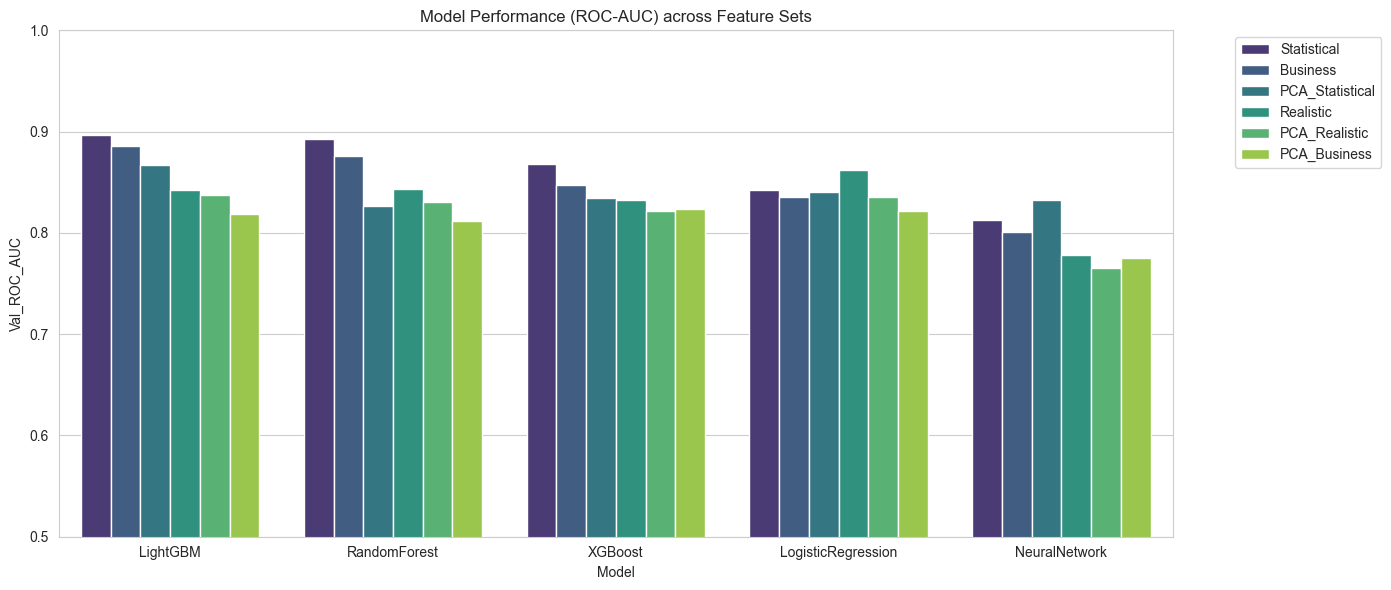

In [42]:
# Create Results DataFrame
results_df = pd.DataFrame(all_results)

if not results_df.empty:
    # Sort by ROC-AUC
    results_df = results_df.sort_values('Val_ROC_AUC', ascending=False)
    
    print("Top 10 Models by Validation ROC-AUC:")
    display(results_df[['Model', 'Dataset', 'Val_Accuracy', 'Val_ROC_AUC']].head(10))
    
    # Visualization
    plt.figure(figsize=(14, 6))
    sns.barplot(data=results_df, x='Model', y='Val_ROC_AUC', hue='Dataset', palette='viridis')
    plt.title('Model Performance (ROC-AUC) across Feature Sets')
    plt.ylim(0.5, 1.0)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("No results to display.")

## 5. Evaluation
In this section, we analyze the performance of the 30 experimental combinations (5 Models $\times$ 6 Feature Sets). We start with a high-level overview to identify patterns, select the best performing model, and then perform a detailed evaluation on the held-out Test Set.

### 5.1 Performance Overview
We visualize the results to identify the top performers and understand how different feature sets impact model performance.

In [34]:
if not results_df.empty:
    print("Top 5 Models by Validation ROC-AUC:")
    display(results_df.sort_values('Val_ROC_AUC', ascending=False).head(5))

    # 2. Heatmap: Models vs Feature Sets
    pivot_table = results_df.pivot(index='Model', columns='Dataset', values='Val_ROC_AUC')
    
    plt.figure(figsize=(12, 6))
    sns.heatmap(pivot_table, annot=True, fmt=".4f", cmap='viridis', linewidths=.5)
    plt.title('Validation ROC-AUC Heatmap')
    plt.tight_layout()
    plt.show()

NameError: name 'results_df' is not defined

### 5.2 Feature Set & Model Analysis
We analyze the distribution of performance scores to determine which feature sets and algorithms are most robust.

In [ ]:
if not results_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Feature Set Comparison
    sns.boxplot(data=results_df, x='Dataset', y='Val_ROC_AUC', palette='Set2', ax=axes[0])
    axes[0].set_title('Performance Distribution by Feature Set')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Model Comparison
    sns.boxplot(data=results_df, x='Model', y='Val_ROC_AUC', palette='Set3', ax=axes[1])
    axes[1].set_title('Performance Distribution by Model')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

### 5.3 Best Model Evaluation on Test Set
We select the model with the highest Validation ROC-AUC and evaluate its performance on the held-out **Test Set** to confirm generalizability.

In [ ]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

if not results_df.empty:
    # 1. Select Best Model
    best_row = results_df.sort_values('Val_ROC_AUC', ascending=False).iloc[0]
    best_model_name = best_row['Model']
    best_dataset_name = best_row['Dataset']
    best_model_instance = best_row['Model_Instance']
    
    print(f"Best Model Selected: {best_model_name} on {best_dataset_name} Set")
    print(f"Validation ROC-AUC: {best_row['Val_ROC_AUC']:.4f}")
    
    # 2. Retrieve Test Data
    if best_dataset_name in data_splits:
        X_test = data_splits[best_dataset_name]['X_test']
        y_test = data_splits[best_dataset_name]['y_test']
        
        # 3. Predict on Test Set
        y_pred_test = best_model_instance.predict(X_test)
        y_prob_test = best_model_instance.predict_proba(X_test)[:, 1] if hasattr(best_model_instance, "predict_proba") else y_pred_test
        
        # 4. Calculate Metrics
        test_acc = accuracy_score(y_test, y_pred_test)
        test_roc = roc_auc_score(y_test, y_prob_test)
        
        print(f"\n--- Test Set Performance ---")
        print(f"Accuracy: {test_acc:.4f}")
        print(f"ROC-AUC : {test_roc:.4f}")
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred_test))
        
        # 5. Visualizations
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # ROC Curve
        RocCurveDisplay.from_estimator(best_model_instance, X_test, y_test, ax=axes[0], name=f"{best_model_name}")
        axes[0].set_title("ROC Curve (Test Set)")
        axes[0].plot([0, 1], [0, 1], 'k--')
        
        # Confusion Matrix
        ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, cmap='Blues', ax=axes[1])
        axes[1].set_title("Confusion Matrix (Test Set)")
        
        plt.tight_layout()
        plt.show()
        
        # 6. Feature Importance (if applicable)
        if hasattr(best_model_instance, 'feature_importances_'):
            importances = best_model_instance.feature_importances_
            feature_names = X_test.columns
            
            # Create DataFrame
            fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
            fi_df = fi_df.sort_values('Importance', ascending=False).head(20)
            
            plt.figure(figsize=(12, 8))
            sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')
            plt.title(f'Top 20 Feature Importances ({best_model_name})')
            plt.tight_layout()
            plt.show()
            
    else:
        print(f"Error: Data split for {best_dataset_name} not found.")